<div style="background:linear-gradient(135deg,#1F3A5F,#3D5A80);padding:34px;border-radius:10px">
<h1 style="color:#fff;margin:0">BottleNeck, notebook augmenté par l'IA</h1>
<p style="color:#fff;margin:6px 0 0;font-size:17px">Projet 13, partie 1. Amélioration critique et documentée du livrable P6</p>
</div>

## Informations
| | |
|---|---|
| **Auteur** | Charles Lippens |
| **Formation** | Data Analyst, OpenClassrooms |
| **Projet** | Projet 13, Pilotez un projet data augmenté avec l'IA |
| **Base de travail** | Notebook du projet 6, « Optimisez la gestion des données d'une boutique » |
| **Client (scénario)** | BottleNeck, marchand de vins |
| **Date** | Juillet 2026 (première version) ; exécution livrée le 4 août 2026 ; textes relus les 24 et 25 septembre 2026 ; textes corrigés et commentaires ajoutés au code le 28 septembre 2026, textes mis à jour le 1er octobre 2026 (jalon J4) et le 7 octobre 2026 (essais C et D relus), sans réexécution |

---
## Objectif de ce notebook
Ce notebook reprend celui du projet 6 et l'améliore avec l'IA. Pour chaque axe, je compare au moins deux options sur sept critères (qualité, biais, temps, reproductibilité, sécurité et conformité, maintenabilité, sobriété), je justifie mon choix et je garde la trace des essais. Les sept critères sont définis dans le document de veille (section 2.1), qui compare les options sur ces critères en section 3.5.

### Les quatre axes d'amélioration, issus de la veille
| Axe | Existant du projet 6 | Options comparées | Décision |
|-----|----------------------|-------------------|----------|
| 1. Qualité des données | Contrôles écrits à la main (`print`) | Pandera (testé), Great Expectations (comparé sur sa documentation) | Pandera retenu |
| 2. Performance et reproductibilité | pandas | Polars, DuckDB | pandas gardé ; Polars ou DuckDB si le volume augmente |
| 3. Détection d'anomalies | Score z sur le prix | Isolation Forest, Local Outlier Factor (essai A) | Isolation Forest ajouté en complément |
| 4. Interprétabilité et documentation | Aucune explication des ventes | Importances du modèle (essai B), valeurs de Shapley (SHAP) | SHAP retenu |

> **Usage de l'IA.** J'ai travaillé avec deux assistants. Les essais du journal ont été faits avec Claude (Anthropic). ChatGPT (OpenAI) m'a servi surtout pour la rédaction, la relecture, la recherche d'idées et le code ; ces échanges n'ont pas été archivés. Je relis et vérifie les propositions avant de les garder, y compris les essais C et D du notebook complémentaire : chiffres recalculés par l'assistant dans un script séparé, relus et relancés par moi le 7 octobre 2026. Le jeu ne contient aucune donnée personnelle (voir 0.2).

**Sommaire.** 0.1 et 0.2 : traçabilité et sécurité. Étape 0 : environnement. Étape 1 : données. Étapes 2 à 5 : axes 1 à 4. Étape 6 : synthèse pour la direction. Étape 7 : versions, puis conclusion. Les essais complémentaires A à D (Local Outlier Factor, importances du modèle, chiffres du réassort, stabilité du modèle) sont dans un notebook à part.

## 0.1 Traçabilité des essais d'IA
Le journal complet est dans la documentation de la démarche (section 2 et annexe A) et dans le dossier `journal_essais_IA`. En résumé :

| Axe | Demande à l'assistant (résumé) | Variantes comparées | Critère décisif | Décision |
|-----|-------------------------------|---------------------|-----------------|----------|
| Qualité | « Convertis ces 9 contrôles manuels en schéma de validation réutilisable » | Contrôles manuels, Pandera, Great Expectations | Lisibilité et rapport automatique | Pandera |
| Performance | « Réécris ce merge+groupby et compare pandas/Polars/DuckDB » | pandas, Polars, DuckDB | Temps au volume réel | pandas aujourd'hui, Polars ou DuckDB si le volume augmente |
| Anomalies | « Propose une détection d'anomalies multivariée vs le Z-score » | Score z, Isolation Forest, Local Outlier Factor | Anomalies vues en plus, et stabilité du résultat | Isolation Forest |
| Interprétabilité | « Explique les facteurs de volume de ventes de façon interprétable » | Importances du modèle, valeurs de Shapley | Explication globale et par référence | SHAP |

Les demandes entre guillemets sont des résumés, gardés tels quels depuis la version du 4 août ; les sections 2.2 et 4.2 en donnent une autre formulation. Le journal en propose un texte complet, reconstitué le 17 septembre.

## 0.2 Sécurité, conformité et sobriété
- **Données.** Le jeu BottleNeck ne contient aucune donnée personnelle : des produits, des prix, des stocks et des ventes par produit. Le RGPD ne s'applique donc pas directement, mais je travaille comme s'il s'appliquait.
- **IA.** L'assistant travaille dans le dossier du projet et lit les sorties des cellules qu'il exécute. Mes demandes portent sur le code, les schémas et les noms de colonnes. Chaque copie des fichiers de données dans son environnement est notée au journal, la première le 17 septembre.
- **Reproductibilité.** Graine fixée (`SEED = 42`), chemins relatifs, versions affichées à l'étape 7 et figées dans le fichier `requirements.txt` du dossier de dépôt, avec les instructions d'exécution du `README.md`.
- **Sobriété.** Des modèles légers (Isolation Forest, gradient boosting peu profond) ; Polars ou DuckDB seulement si le volume le justifie.

# Étape 0. Préparation de l'environnement

In [1]:
# Installation : de préférence « pip install -r requirements.txt » (versions figées, voir le README).
# À défaut, décommenter la ligne suivante (versions non figées) :
# %pip install pandas numpy matplotlib seaborn scikit-learn pandera polars duckdb shap openpyxl pyarrow -q

import warnings, time, platform, random
# Avertissements masqués pour alléger les sorties
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

# Graine unique : séparation des données, Isolation Forest, modèle et jeu fictif de l'étape 3
SEED = 42
random.seed(SEED); np.random.seed(SEED)
pd.set_option('display.max_columns', None)
plt.rcParams.update({'figure.dpi':110,'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
ORANGE, TEAL, DARK, GREY = '#FF7200', '#33A5B6', '#1f2937', '#94a3b8'
print('Python', platform.python_version())

Python 3.11.15


# Étape 1. Chargement des données sources
Les trois fichiers du projet 6 : `erp.xlsx` (825 lignes, 6 colonnes), `web.xlsx` (1 513 lignes, 29 colonnes) et `liaison.xlsx` (825 lignes, 2 colonnes). Les ventes couvrent le mois d'octobre. Le notebook cherche le dossier des données à quatre emplacements habituels, pour éviter de modifier les chemins d'un poste à l'autre.

In [2]:
from pathlib import Path
# Dossier des données cherché à ces quatre emplacements, dans l'ordre : aucun chemin à modifier d'un poste à l'autre
CANDIDATS = [Path('Data+Bottleneck'), Path('../Data+Bottleneck'),
             Path('P6_donnees/Data+Bottleneck'), Path('../P6_donnees/Data+Bottleneck')]
DATA_DIR = next((p for p in CANDIDATS if (p/'erp.xlsx').exists()), None)
assert DATA_DIR is not None, "Placez erp/web/liaison.xlsx dans un dossier 'Data+Bottleneck' à côté du notebook."
print('Données chargées depuis :', DATA_DIR)
erp     = pd.read_excel(DATA_DIR/'erp.xlsx')
web     = pd.read_excel(DATA_DIR/'web.xlsx')
liaison = pd.read_excel(DATA_DIR/'liaison.xlsx')
print('erp', erp.shape, '| web', web.shape, '| liaison', liaison.shape)
erp.head(3)

Données chargées depuis : Data+Bottleneck


erp (825, 6) | web (1513, 29) | liaison (825, 2)


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64


# Étape 2. Axe 1, qualité des données

## 2.1 L'existant du projet 6 : des contrôles manuels dispersés
*Hypothèse* : un contrat de données déclaratif peut remplacer les contrôles écrits à la main.

Dans le projet 6, les erreurs étaient repérées par une suite de `print` répartis dans le notebook (environ 55 lignes pour neuf contrôles). Cela fonctionnait, mais ces contrôles n'étaient ni réutilisables ni résumés dans un rapport. Le tableau ci-dessous les refait dans une seule cellule.

In [3]:
# Fiches produits du site, sans les lignes de pièces jointes (post_type « attachment »)
web_prod = web[web['post_type']=='product'].copy()
anomalies = {
 'ERP, prix négatifs'              : int((erp['price']<0).sum()),
 'ERP, stocks négatifs'            : int((erp['stock_quantity']<0).sum()),
 'ERP, prix d’achat > prix de vente'    : int((erp['purchase_price']>erp['price']).sum()),
 'WEB, lignes attachment à filtrer': int((web['post_type']=='attachment').sum()),
 'WEB, SKU manquants'              : int(web_prod['sku'].isna().sum()),
 # ce compte (1) est la seconde fiche sans SKU : pandas voit deux cases vides comme un doublon
 'WEB, SKU en doublon'             : int(web_prod['sku'].duplicated().sum()),
 'WEB, ventes négatives'           : int((web_prod['total_sales']<0).sum()),
 'LIAISON, id_web manquants'       : int(liaison['id_web'].isna().sum()),
 # valeur saisie en dur, reprise du projet 6 (identifiants web contenant un tiret)
 'LIAISON, formats non standard'   : 3,
}
pd.Series(anomalies, name='occurrences').to_frame()

,occurrences
"ERP, prix négatifs",3
"ERP, stocks négatifs",2
"ERP, prix d’achat > prix de vente",7
"WEB, lignes attachment à filtrer",714
"WEB, SKU manquants",2
"WEB, SKU en doublon",1
"WEB, ventes négatives",2
"LIAISON, id_web manquants",91
"LIAISON, formats non standard",3


**Constat.** Neuf types d'erreurs, là où l'énoncé du projet 6 en demandait au moins huit. « SKU en doublon » compte en fait la seconde fiche sans SKU : pandas voit deux cases vides comme un doublon. À l'inverse, le tableau oublie deux fiches de l'ERP dont le statut de stock contredit la quantité. Le compte reste donc de neuf. « Formats non standard » (3) est saisi en dur, repris du projet 6 (identifiants web contenant un tiret). Ces contrôles donnent des comptes, pas la liste des lignes en faute : l'assistant propose de les regrouper dans un contrat de données.

## 2.2 Option retenue : la validation déclarative avec Pandera
> *Demande à l'assistant (résumé)* : « Transforme ces 9 contrôles en un schéma typé, réutilisable, qui produit un rapport des lignes en violation. Compare Pandera et Great Expectations. »

Great Expectations est très complet (rapports, historique des validations) mais long à mettre en place ; je l'ai comparé sur sa documentation, sans l'exécuter. Pandera se lit facilement et tient dans une seule cellule : je le retiens. Great Expectations deviendrait utile si les contrôles tournaient chaque jour en production, avec un suivi dans le temps.

In [4]:
import pandera.pandas as pa
from pandera.pandas import Column, Check, DataFrameSchema

# Le contrat : un type et une règle par colonne, plus une règle sur la ligne entière (prix d'achat au plus égal au prix de vente)
erp_schema = DataFrameSchema({
    'product_id'    : Column(int,   Check.greater_than(0), unique=True),
    'onsale_web'    : Column(int,   Check.isin([0,1])),
    'price'         : Column(float, Check.greater_than(0)),
    'stock_quantity': Column(int,   Check.greater_than_or_equal_to(0)),
    'stock_status'  : Column(str,   Check.isin(['instock','outofstock'])),
    'purchase_price': Column(float, Check.greater_than(0)),
}, checks=[Check(lambda d: d['purchase_price'] <= d['price'],
                 error='marge_negative (prix d’achat > prix de vente)')],
   name='contrat_qualite_erp')

try:
    # lazy=True : relève toutes les infractions au lieu de s'arrêter à la première
    erp_schema.validate(erp, lazy=True)
    print('ERP conforme au contrat de qualité')
except pa.errors.SchemaErrors as e:
    fc = e.failure_cases
    # Le contrôle de marge porte sur tout le tableau :
    # il renvoie un cas par colonne pour chaque ligne fautive.
    # On compte donc les lignes uniques en infraction, et non les cas renvoyés.
    rapport = (fc.groupby('check')['index'].nunique()
                 .rename('lignes_en_infraction').sort_values(ascending=False))
    n_lignes = fc['index'].nunique()
    print(f"Contrat de qualité : {n_lignes} lignes en infraction sur {len(erp)} lignes ERP "
          f"({n_lignes/len(erp)*100:.1f} %)")
    display(rapport.to_frame())

Contrat de qualité : 9 lignes en infraction sur 825 lignes ERP (1.1 %)


,lignes_en_infraction
check,
marge_negative (prix d’achat > prix de vente),7
greater_than(0),3
greater_than_or_equal_to(0),2


**Décision (axe 1).** Le contrat Pandera remplace les contrôles manuels de l'ERP (prix, stock, marge). Il tient en 14 lignes, contre environ 55 pour les neuf contrôles du projet 6, qui couvraient aussi le site et la liaison. Il produit un rapport à chaque extraction : 9 lignes en faute pour 12 infractions, car les 3 prix négatifs sont aussi des marges négatives. Prochaine étape : ajouter au contrat les contrôles du site et de la liaison, restés dans la cellule d'audit.

## 2.3 Nettoyage et jointure, base des étapes suivantes
J'écarte les 91 lignes de la table de liaison sans `id_web` et les 2 fiches du site sans SKU, puis je joins l'ERP à la liaison, et le résultat au site. Il reste 714 produits : c'est la table de toutes les étapes suivantes.

In [5]:
# lia : liaison sans id_web manquant ; wpc : fiches produits du site avec un SKU, sans doublon
lia = liaison.dropna(subset=['id_web']).copy(); lia['id_web'] = lia['id_web'].astype(str)
wpc = web_prod.dropna(subset=['sku']).drop_duplicates(subset=['sku']).copy(); wpc['sku'] = wpc['sku'].astype(str)

# Jointures internes : ne restent que les produits présents dans les trois fichiers (714)
df = (erp.merge(lia, on='product_id', how='inner')
         .merge(wpc, left_on='id_web', right_on='sku', how='inner'))
# Chiffre d'affaires d'octobre, et taux de marge rapporté au prix affiché (définition gardée dans tout le dossier)
df['ca_par_article'] = df['price'] * df['total_sales']
df['marge_unitaire'] = df['price'] - df['purchase_price']
df['taux_marge']     = np.where(df['price']>0, df['marge_unitaire']/df['price']*100, np.nan)
print(f"Périmètre analysable : {len(df)} produits")
print(f"CA total : {df['ca_par_article'].sum():,.0f} EUR  |  Ventes : {int(df['total_sales'].sum()):,} unites")

Périmètre analysable : 714 produits
CA total : 143,680 EUR  |  Ventes : 5,751 unites


# Étape 3. Axe 2, performance et reproductibilité

## 3.1 Le besoin
*Hypothèse* : au volume actuel, changer d'outil n'apporte rien ; le gain n'apparaît qu'à grande échelle.
> *Demande à l'assistant (résumé)* : « Réécris ce merge+groupby et compare pandas/Polars/DuckDB »

Au volume réel (825 lignes dans l'ERP, 714 produits après jointure), tout est instantané. Je compare pandas, Polars et DuckDB sur une même opération (jointure, regroupement, somme) pour savoir si un autre outil se justifierait avec plus de volume, par exemple plusieurs boutiques ou l'historique des ventes.
> *Critère* : le temps médian, sur sept exécutions au volume réel et cinq à deux millions de ventes.

In [6]:
import polars as pl, duckdb

# Entrées communes aux trois outils : l'ERP rapproché de la liaison, et les ventes du site par SKU
erp_j = erp.merge(lia, on='product_id', how='inner'); erp_j['id_web'] = erp_j['id_web'].astype(str)
web_j = wpc[['sku','total_sales']].copy()

# Trois versions de la même opération. Polars et DuckDB partent des tableaux pandas : la conversion est comprise dans leur temps
def pipe_pandas(e, w):
    m = e.merge(w, left_on='id_web', right_on='sku', how='inner')
    m['ca'] = m['price']*m['total_sales']
    return m.groupby('stock_status').agg(ca=('ca','sum'), n=('product_id','size'))

def pipe_polars(e, w):
    d = pl.from_pandas(e).join(pl.from_pandas(w), left_on='id_web', right_on='sku', how='inner')
    return (d.with_columns((pl.col('price')*pl.col('total_sales')).alias('ca'))
             .group_by('stock_status').agg(pl.col('ca').sum(), pl.len()))

def pipe_duckdb(e, w):
    con = duckdb.connect(); con.register('e', e); con.register('w', w)
    r = con.execute("SELECT e.stock_status, SUM(e.price*w.total_sales) ca, COUNT(*) n "
                    "FROM e JOIN w ON e.id_web=w.sku GROUP BY e.stock_status").df()
    con.close(); return r

# Temps médian de n exécutions, pour lisser les écarts d'un passage à l'autre
def bench(fn, *a, n=7):
    ts=[]
    for _ in range(n):
        t=time.perf_counter(); fn(*a); ts.append(time.perf_counter()-t)
    return float(np.median(ts))*1000  # médiane, en millisecondes

reel = {'pandas': bench(pipe_pandas, erp_j, web_j),
        'Polars': bench(pipe_polars, erp_j, web_j),
        'DuckDB': bench(pipe_duckdb, erp_j, web_j)}
print("Volumétrie réelle (825 lignes), temps médian en ms :")
for k,v in reel.items(): print(f'  {k:7s}: {v:6.2f} ms')

Volumétrie réelle (825 lignes), temps médian en ms :
  pandas :   9.94 ms
  Polars :   2.53 ms
  DuckDB :  32.33 ms


## 3.2 Test à deux millions de ventes
Je génère un jeu fictif de 50 000 produits et 2 millions de ventes, tiré au hasard avec la graine fixée, pour voir si l'écart entre les outils devient sensible. Un seul volume est testé : le seuil de bascule n'est pas mesuré. Les temps de Polars et de DuckDB comprennent la conversion depuis les tableaux pandas et, pour DuckDB, l'ouverture de la connexion.

In [7]:
# Jeu fictif tiré avec la graine fixée : 50 000 produits et 2 millions de ventes
rng = np.random.default_rng(SEED)
NPROD, NSALES = 50_000, 2_000_000
prod = pd.DataFrame({'product_id':np.arange(NPROD), 'price':rng.uniform(5,200,NPROD),
                     'cat':rng.integers(0,40,NPROD)})
sales = pd.DataFrame({'product_id':rng.integers(0,NPROD,NSALES), 'qty':rng.integers(1,12,NSALES)})

# Même opération sur le jeu fictif : jointure des ventes et des produits, chiffre d'affaires par catégorie
def big_pandas():
    d = sales.merge(prod, on='product_id'); d['ca']=d['price']*d['qty']
    return d.groupby('cat').agg(ca=('ca','sum'))
def big_polars():
    d = pl.from_pandas(sales).join(pl.from_pandas(prod), on='product_id')
    return d.with_columns((pl.col('price')*pl.col('qty')).alias('ca')).group_by('cat').agg(pl.col('ca').sum())
def big_duckdb():
    con=duckdb.connect(); con.register('p',prod); con.register('s',sales)
    r=con.execute("SELECT p.cat, SUM(p.price*s.qty) ca FROM s JOIN p USING(product_id) GROUP BY p.cat").df()
    con.close(); return r

scale = {'pandas':bench(big_pandas,n=5), 'Polars':bench(big_polars,n=5), 'DuckDB':bench(big_duckdb,n=5)}
print(f'Montée en charge ({NSALES:,} ventes), temps médian en ms :')
for k,v in scale.items(): print(f'  {k:7s}: {v:7.1f} ms   (x{scale["pandas"]/v:.1f} vs pandas)')

Montée en charge (2,000,000 ventes), temps médian en ms :
  pandas :   240.3 ms   (x1.0 vs pandas)
  Polars :    58.7 ms   (x4.1 vs pandas)
  DuckDB :    81.7 ms   (x2.9 vs pandas)


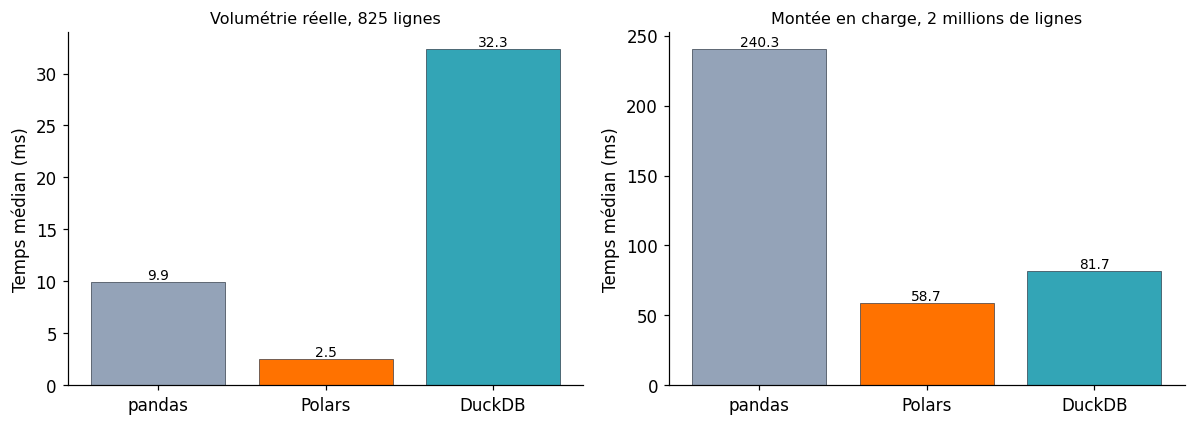

In [8]:
# À gauche le volume réel, à droite le jeu fictif ; le temps est écrit au-dessus de chaque barre
fig, ax = plt.subplots(1, 2, figsize=(11,4))
for a,(d,titre) in zip(ax, [(reel,'Volumétrie réelle, 825 lignes'), (scale,'Montée en charge, 2 millions de lignes')]):
    keys=list(d); vals=[d[k] for k in keys]
    a.bar(keys, vals, color=[GREY,ORANGE,TEAL], edgecolor=DARK, linewidth=.4)
    for i,v in enumerate(vals): a.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)
    a.set_title(titre, fontsize=10.5); a.set_ylabel('Temps médian (ms)')
plt.tight_layout(); plt.show()

**Décision (axe 2).** Au volume réel, pandas suffit : les trois outils répondent en moins de 40 ms, et DuckDB est même le plus lent, à cause de son temps de démarrage. À deux millions de ventes, Polars est 4,1 fois plus rapide que pandas et DuckDB 2,9 fois le 4 août (exécution livrée). Sur mon poste, le 25 septembre, c'est 8,1 et 5,7 fois. Le gain dépend de la machine ; la décision ne change pas. La mémoire n'a pas été mesurée.

*Recommandation* : garder pandas, et passer à Polars ou DuckDB si BottleNeck historise ses ventes ou ouvre d'autres boutiques.

# Étape 4. Axe 3, détection d'anomalies

## 4.1 L'existant : le score z sur le prix
*Hypothèse* : une détection sur plusieurs variables voit des cas que la méthode sur le seul prix ignore.

Le projet 6 repère les prix extrêmes avec le score z (Z-score dans les sorties) et avec l'écart interquartile ; je garde le score z comme référence. Un prix est signalé s'il s'écarte de la moyenne de plus de trois écarts types. Cette méthode ne regarde qu'une variable à la fois : elle ne voit pas les combinaisons suspectes, comme un prix normal avec une marge aberrante.

In [9]:
# Score z : écart du prix à la moyenne, en nombre d'écarts types ; au-delà de 3, le prix est signalé
mu, sd = df['price'].mean(), df['price'].std()
df['z'] = (df['price']-mu)/sd
df['z_anom'] = df['z'].abs() > 3
print(f"Z-score : {int(df['z_anom'].sum())} anomalies (prix moyen {mu:.2f} EUR, écart type {sd:.2f})")

Z-score : 13 anomalies (prix moyen 32.33 EUR, écart type 27.60)


## 4.2 Option retenue : Isolation Forest, sur plusieurs variables
> *Demande à l'assistant (résumé)* : « Propose une détection d'anomalies multivariée et compare-la au Z-score sur ces variables. »

Local Outlier Factor a aussi été testé (notebook d'essais complémentaires, essai A) : sa liste d'anomalies change beaucoup selon le nombre de voisins. Je retiens Isolation Forest : sa liste varie peu quand on change sa graine, et il a peu de réglages. Avec `contamination=0.05`, il signale toujours 5 % des produits, soit 36 sur 714.

In [10]:
from sklearn.ensemble import IsolationForest
feats = ['price','purchase_price','stock_quantity','total_sales','taux_marge']
# Valeurs manquantes remplacées par la médiane de chaque colonne
X = df[feats].fillna(df[feats].median())
# contamination=0.05 : le modèle signale toujours 5 % des produits (36 sur 714)
iso = IsolationForest(contamination=0.05, n_estimators=200, random_state=SEED)
df['if_anom'] = iso.fit_predict(X) == -1

n_if, n_z = int(df['if_anom'].sum()), int(df['z_anom'].sum())
overlap   = int((df['if_anom'] & df['z_anom']).sum())
print(f"Isolation Forest : {n_if} anomalies | Z-score : {n_z} | communes : {overlap}")
print(f"{int((df['if_anom'] & ~df['z_anom']).sum())} anomalies multivariées captées par Isolation Forest et invisibles à la méthode univariée")
# Les trois anomalies vues par Isolation Forest seul qui ont la marge la plus faible
display(df[df['if_anom'] & ~df['z_anom']].nsmallest(3,'taux_marge')[['price','purchase_price','total_sales','taux_marge','stock_quantity']])

Isolation Forest : 36 anomalies | Z-score : 13 | communes : 10
26 anomalies multivariées captées par Isolation Forest et invisibles à la méthode univariée


,price,purchase_price,total_sales,taux_marge,stock_quantity
201,12.65,77.48,0.0,-512.490119,97
69,39.00,24.86,8.0,36.256410,123
550,19.50,12.07,10.0,38.102564,125


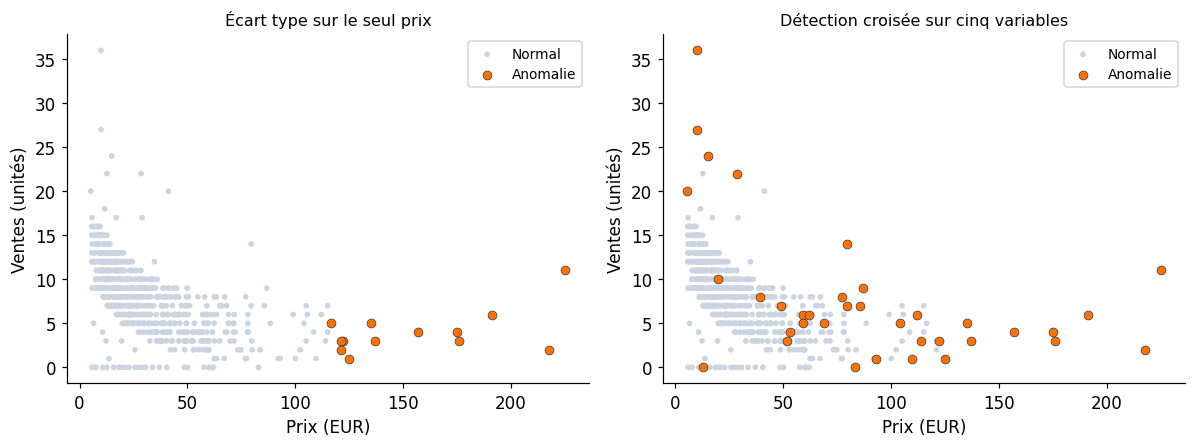

In [11]:
# Même nuage prix et ventes : anomalies du score z à gauche, d'Isolation Forest à droite
fig, ax = plt.subplots(1, 2, figsize=(11,4.2))
for a,(col,titre) in zip(ax, [('z_anom','Écart type sur le seul prix'),
                               ('if_anom','Détection croisée sur cinq variables')]):
    n = df[~df[col]]; an = df[df[col]]
    a.scatter(n['price'], n['total_sales'], s=14, c='#cbd5e1', edgecolors='none', label='Normal')
    a.scatter(an['price'], an['total_sales'], s=34, c=ORANGE, edgecolors=DARK, linewidths=.4, label='Anomalie')
    a.set_title(titre, fontsize=10.5); a.set_xlabel('Prix (EUR)'); a.set_ylabel('Ventes (unités)'); a.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Décision (axe 3).** Je garde le score z, simple à expliquer au métier, et j'ajoute Isolation Forest pour les combinaisons anormales : il signale 26 produits que le score z ne voit pas. Dans le tableau, le premier est affiché en ligne à 12,65 € pour 77,48 € d'achat, sans vente en octobre ; les deux suivants ont surtout un stock très élevé (123 et 125 unités). Comme le nombre d'alertes est fixé d'avance, certaines seront fausses : le métier les valide avant toute correction.

# Étape 5. Axe 4, interprétabilité et documentation

## 5.1 Quels facteurs expliquent le volume de ventes ?
*Hypothèse* : le volume de ventes s'explique par quelques facteurs qu'on peut identifier et montrer.
> *Demande à l'assistant (résumé)* : « Explique les facteurs de volume de ventes de façon interprétable »

Je modélise le volume de ventes pour voir quelles variables comptent le plus, ce qui aide à prioriser le réassort. J'entraîne un `GradientBoostingRegressor`, puis je l'explique avec les valeurs de Shapley (bibliothèque SHAP). La comparaison avec les importances du modèle est dans le notebook d'essais complémentaires (essai B).

In [12]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

mfeats = ['price','purchase_price','taux_marge','stock_quantity','average_rating','rating_count','onsale_web']
# Les colonnes d'avis valent 0 partout : gardées pour montrer qu'elles ne pèsent rien
M = df[mfeats].fillna(0); y = df['total_sales']
# 75 % des produits pour l'entraînement, 25 % pour le test (179 références)
Xtr, Xte, ytr, yte = train_test_split(M, y, test_size=0.25, random_state=SEED)
gb = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=SEED).fit(Xtr, ytr)
print(f"R2 (test) = {r2_score(yte, gb.predict(Xte)):.3f}  |  MAE = {mean_absolute_error(yte, gb.predict(Xte)):.2f} unités")

R2 (test) = 0.724  |  MAE = 1.54 unités


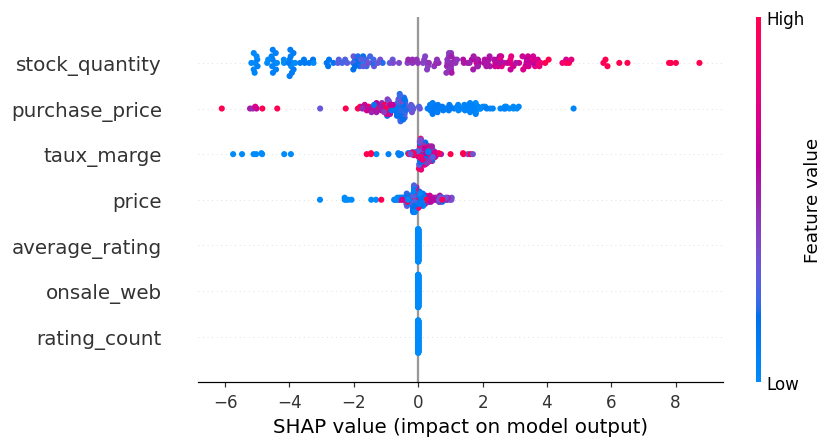

In [13]:
import shap
# Valeurs de Shapley : la part de chaque variable dans chaque prédiction du jeu de test
explainer = shap.TreeExplainer(gb)
sv = explainer.shap_values(Xte)
shap.summary_plot(sv, Xte, show=False, plot_size=(8,4.2))
plt.tight_layout(); plt.show()

**Décision (axe 4).** Sur le jeu de test, le modèle explique environ 72 % de la variation des ventes. Son erreur moyenne est de 1,5 unité, deux fois moins que celle d'une prédiction naïve (3,5 unités). En validation croisée, ce pouvoir explicatif va de 0,53 à 0,76 selon la partition (0,67 en moyenne, essai D du notebook complémentaire) : de quoi lire les facteurs ; prévoir demanderait plusieurs mois de ventes. SHAP place le stock en tête, devant le prix d'achat et le taux de marge. Les colonnes d'avis ne pèsent rien : elles valent 0 pour les 714 produits (avis désactivés sur le site). `onsale_web` non plus : il vaut 1 pour 713 produits sur 714. Le stock est donc le premier facteur du modèle. Le lien joue dans les deux sens : on vend ce qu'on a en stock, et on stocke ce qui se vend. De plus, le stock est relevé le 31 octobre, après les ventes du mois. Je m'en sers pour prioriser le réassort, sans en tirer de cause.

*Lecture du graphique : un point par référence du jeu de test (179 références) ; à droite de 0, la variable augmente la prédiction ; rouge pour les valeurs élevées, bleu pour les faibles. Les libellés de SHAP sont en anglais : « SHAP value » est l'effet sur la prédiction, en unités vendues, et « Feature value » la valeur de la variable, de « Low » (faible) à « High » (élevée).*

# Étape 6. Synthèse pour la direction
La courbe classe les 689 références qui vendent, de la plus forte à la plus faible en chiffre d'affaires, et cumule leur part du total.

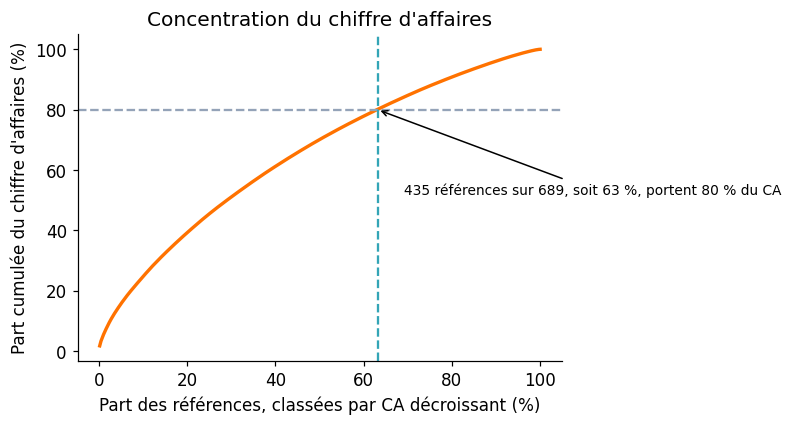

In [14]:
ca_total = df['ca_par_article'].sum()
# Références qui vendent, classées par chiffre d'affaires décroissant, puis part cumulée du total
s = df[df['ca_par_article']>0].sort_values('ca_par_article', ascending=False).copy()
s['cum'] = s['ca_par_article'].cumsum()/ca_total*100
# +1 : la référence qui fait franchir les 80 %
nb80 = int((s['cum']<=80).sum())+1
fig, ax = plt.subplots(figsize=(7,4))
xp = np.arange(1,len(s)+1)/len(s)*100
ax.plot(xp, s['cum'].values, color=ORANGE, lw=2.2)
p80 = nb80/len(s)*100
ax.axhline(80, color=GREY, ls='--'); ax.axvline(p80, color=TEAL, ls='--')
ax.annotate(f'{nb80} références sur {len(s)}, soit {p80:.0f} %, portent 80 % du CA', (p80,80), xytext=(p80+6,52),
            fontsize=9, arrowprops=dict(arrowstyle='->'))
ax.set_xlabel('Part des références, classées par CA décroissant (%)'); ax.set_ylabel("Part cumulée du chiffre d'affaires (%)")
ax.set_title("Concentration du chiffre d'affaires"); plt.tight_layout(); plt.show()

**Résultats**
- 714 produits analysables après nettoyage et jointure.
- 143 680 € de chiffre d'affaires pour 5 751 unités vendues, soit environ 25 € par unité.
- Un chiffre d'affaires peu concentré : il faut 435 références, 63 % de celles qui vendent, pour faire 80 % du total.
- Marge moyenne de 47,4 % du prix affiché (médiane 48,3 %) et 45 produits en rupture de stock. Ces valeurs sont calculées dans le notebook complémentaire (essai C), sur la même table ; il montre aussi que 14 des 435 références clés ont un stock nul.

**Recommandations**
1. Faire passer chaque import de l'ERP par le contrat Pandera.
2. Surveiller d'abord le stock des références qui font le plus de chiffre d'affaires : c'est le premier facteur du modèle selon SHAP, un lien statistique dont je ne tire aucune cause.
3. Passer à Polars ou DuckDB quand l'historique des ventes fera grossir le volume.
4. Faire valider par le métier les alertes d'Isolation Forest avant toute correction.

# Étape 7. Versions des bibliothèques
Ce sont les versions de l'exécution du 4 août. Le fichier `requirements.txt` du dossier de dépôt les fige pour une nouvelle installation.

In [15]:
# Versions de cette exécution ; le requirements.txt du dossier de dépôt les fige
import sklearn, pandera, polars, duckdb, shap, matplotlib
for m in [np, pd, sklearn, pandera, polars, duckdb, shap, matplotlib]:
    print(f"{m.__name__:12s} {m.__version__}")
print('SEED =', SEED)

numpy        2.4.4
pandas       3.0.2
sklearn      1.8.0
pandera      0.32.1
polars       1.43.2
duckdb       1.5.5
shap         0.51.0
matplotlib   3.10.9
SEED = 42


---
# Conclusion
Je retiens quatre décisions : un contrat Pandera pour l'ERP, pandas tant que le volume reste faible, Isolation Forest en complément du score z, et les valeurs de Shapley pour expliquer les ventes. Trois limites restent : le contrat ne couvre que l'ERP, le test de charge porte sur un seul volume, et le pouvoir explicatif du modèle dépend de la partition des données (0,53 à 0,76). Les alertes d'Isolation Forest sont à valider par le métier. Prochaines étapes : étendre le contrat au site et à la table de liaison, mesurer plusieurs volumes pour situer le seuil de bascule, et recalculer chaque mois les listes du réassort (essai C).

*Historique. Code et sorties de l'exécution du 4 août 2026 (les sorties gardent le format anglais des nombres). Textes relus les 24 et 25 septembre 2026. Le 28 septembre 2026, textes corrigés et commentaires ajoutés au code, sans réexécution : le code exécuté et les sorties sont inchangés.*

*Reproductibilité. Le 25 septembre 2026, ce code a tourné sans erreur sur mon poste (Anaconda, Python 3.13.9, pandas 2.2.3 ; poste non vierge) : mêmes chiffres métier, temps différents. Le 28 septembre, l'assistant l'a réexécuté dans un environnement neuf créé avec le `requirements.txt` : mêmes sorties, temps exceptés. Le 30 septembre, sur mon poste, une copie de ce notebook a tourné sans erreur dans un environnement neuf créé avec le seul `requirements.txt` : mêmes sorties, hors temps de calcul et version de Python (jalon J4). Détail dans le journal des essais.*